# radSeq — Temporal Radar Sequence Generation via DiT

Walkthrough of the pipeline: simulator → cached dataset → temporal-only DiT → diffusion training → sampling → physics metrics.

- Research text: `../prop.md`
- Design spec: `../docs/superpowers/specs/2026-07-18-temporal-radar-dit-design.md`
- Implementation plan: `../docs/superpowers/plans/2026-07-19-temporal-radar-dit.md`

**The idea in one paragraph:** RD maps have no long-range spatial correlations (a target here is physically independent of a target there), so the DiT attends **only across time**: each of the 225 overlapping 8×8 patches (stride 4) is an independent length-16 token sequence. Overlap keeps moving targets visible in adjacent patches. Physics losses (temporal smoothness, constant-velocity trajectories, stable Doppler centroids) push generated sequences toward plausible kinematics, and adaLN conditioning makes motion/clutter/class controllable.

In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # stay off the GPU while training runs
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')                        # run from repo root: config/cache paths are relative to it
sys.path.insert(0, '.')
import torch, yaml
import matplotlib.pyplot as plt
torch.manual_seed(0)
cfg = yaml.safe_load(open('configs/base.yaml'))
cfg

{'data': {'n_train': 20000,
  'n_val': 2000,
  'seq_len': 16,
  'frame_interval': 0.5,
  'cache_dir': 'data/cache',
  'shard_size': 1000,
  'seed': 1234},
 'model': {'patch': 8, 'stride': 4, 'dim': 256, 'depth': 8, 'heads': 8},
 'diffusion': {'timesteps': 1000},
 'train': {'batch_size': 16,
  'lr': 0.0001,
  'weight_decay': 0.0,
  'epochs': 100,
  'lambda_smooth': 0.1,
  'lambda_traj': 0.01,
  'lambda_doppler': 0.01,
  'phase': 1,
  'ckpt_dir': 'checkpoints',
  'wandb': False},
 'sample': {'ddim_steps': 50}}

## 1. The simulator

`TemporalRadarSimulator` extends the RDDiffusion single-frame generator to L=16 frames:
- **Targets** move kinematically: $r_\ell = r_0 + v_0 \ell T_f + \tfrac12 a (\ell T_f)^2$, Doppler tracks $v_\ell = v_0 + a\ell T_f$ (rejection-sampled to stay on-grid). Classes: 0 = steady point, 1 = Swerling-1 fluctuating, 2 = range-extended (3 scatterers, −3 dB flanks).
- **Clutter** is SIRP (K-distributed texture × correlated speckle) whose Gaussian innovations follow AR(1) with coefficient ρ — ρ=0 gives independent frames, ρ→1 frozen clutter.
- Output: log-magnitude RD sequence + full ground truth (continuous bin trajectories, v₀, a, class, env params) — labels come free because we own the scene.

{'x': (16, 64, 64), 'traj': (5, 16, 2), 'v0': (5,), 'acc': (5,), 'cls': (5,), 'env': (3,), 'n_targets': 5}


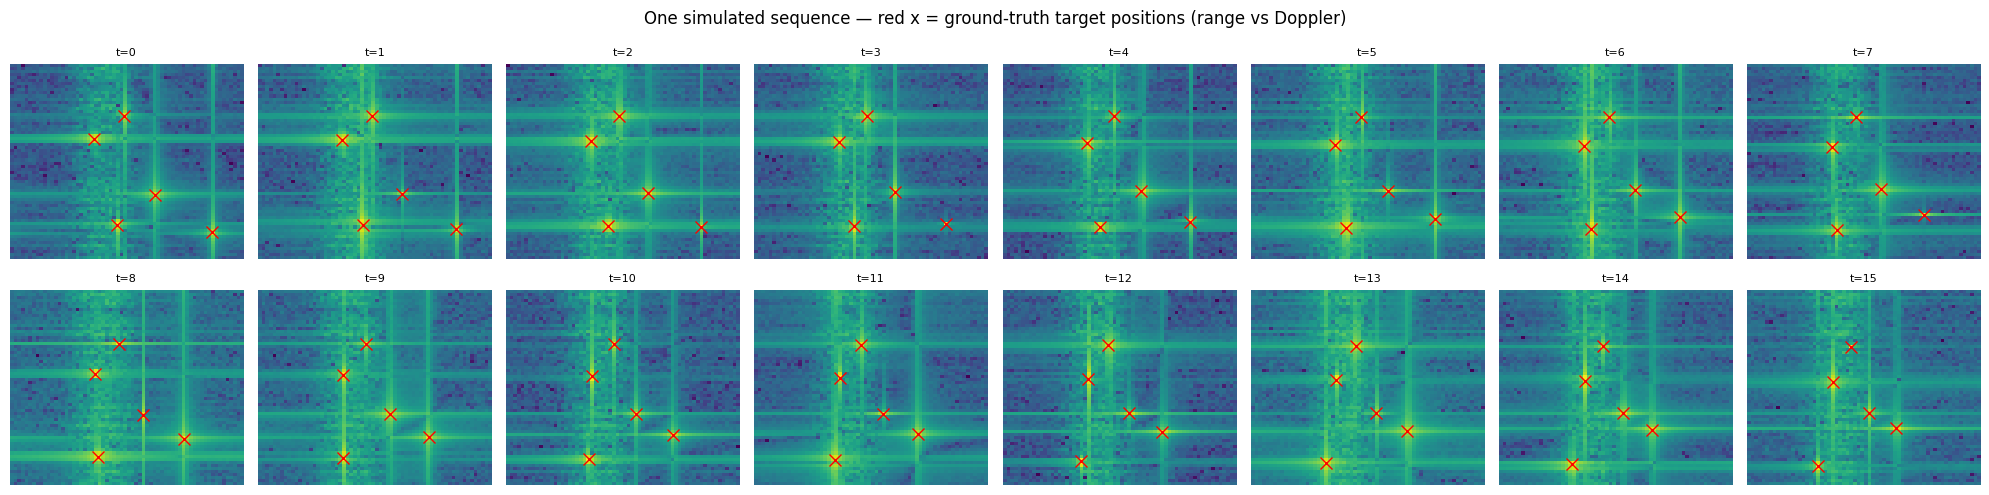

In [2]:
from src.simulator import TemporalRadarSimulator

sim = TemporalRadarSimulator(seq_len=16, scnr=10.0, rho_clutter=0.9)
out = sim.gen_sequence()
print({k: (tuple(v.shape) if torch.is_tensor(v) else v) for k, v in out.items()})

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(out['x'][i], origin='lower', cmap='viridis', aspect='auto')
    for m in range(out['n_targets']):
        ax.plot(out['traj'][m, i, 1], out['traj'][m, i, 0], 'rx', ms=8)
    ax.set_title(f't={i}', fontsize=8); ax.axis('off')
fig.suptitle('One simulated sequence — red x = ground-truth target positions (range vs Doppler)')
plt.tight_layout(); plt.show()

Watch the red crosses drift smoothly across frames — that motion (plus the slowly-evolving clutter strip) is exactly what the model must learn to reproduce.

## 2. The cached dataset

20k train / 2k val sequences pre-generated into `data/cache/` shards with normalization stats locked from the train split (`stats.pt`, recorded in `manifest.yaml`).

In [3]:
from src.dataset import RadarSequenceDataset, denormalize
ds = RadarSequenceDataset('data/cache', 'val')
print(len(ds), 'val sequences | stats:', ds.stats)
item = ds[0]
print('normalized x:', item['x'].shape, f"mean {item['x'].mean():.2f} std {item['x'].std():.2f}")
print('padded targets:', item['traj'].shape, '| real targets:', int(item['n_targets']))

2000 val sequences | stats: {'mean': 41.47939017848969, 'std': 11.065155705714547}
normalized x: torch.Size([16, 64, 64]) mean -0.30 std 0.92
padded targets: torch.Size([5, 16, 2]) | real targets: 3


## 3. Overlapping patches + temporal-only attention

p=8, s=4 → 15×15 = 225 patches per 64×64 frame. `unpatchify` averages overlaps so the round-trip is exact. The DiT reshapes tokens (B, L, 225, d) → (B·225, L, d): every spatial site attends only over its own 16-frame history — spatial independence is exact by construction (there is a unit test that proves it).

In [4]:
from src.patching import patchify, unpatchify
from src.dit import TemporalDiT

x = item['x'][None]                       # (1, 16, 64, 64)
tok = patchify(x)
print('tokens:', tok.shape, '| roundtrip exact:', torch.allclose(unpatchify(tok), x, atol=1e-5))

model = TemporalDiT()
n_params = sum(p.numel() for p in model.parameters())
print(f'TemporalDiT: {n_params/1e6:.1f}M params')
with torch.no_grad():
    eps_hat = model(x, torch.tensor([500]))
print('eps_hat:', eps_hat.shape, '| zero at init (adaLN-Zero):', eps_hat.abs().max().item())

tokens: torch.Size([1, 16, 225, 64]) | roundtrip exact: True
TemporalDiT: 9.8M params


eps_hat: torch.Size([1, 16, 64, 64]) | zero at init (adaLN-Zero): 0.0


## 4. Diffusion + losses

DDPM, T=1000, cosine schedule, ε-prediction. Training loss (phase-dependent):
$$\mathcal{L} = \mathcal{L}_{DiT} + \lambda_s \mathcal{L}_{smooth} + \underbrace{\lambda_t \mathcal{L}_{traj} + \lambda_d \mathcal{L}_{Doppler}}_{phase\geq2}$$
The trajectory/Doppler losses use GT-centered 5×5 windows + soft-argmax, so they are differentiable and the target-association problem is solved by construction.

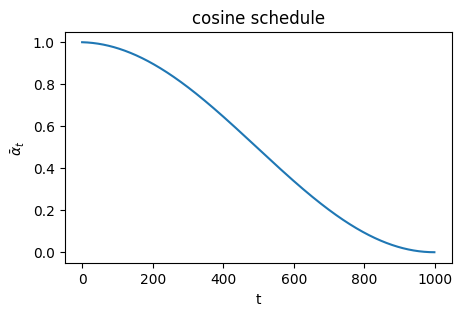

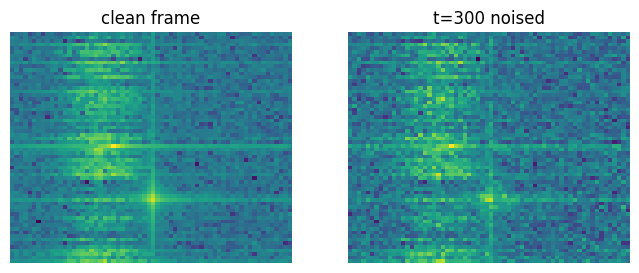

In [5]:
from src.diffusion import GaussianDiffusion
diff = GaussianDiffusion(1000)
plt.figure(figsize=(5, 3))
plt.plot(diff.alphas_bar); plt.xlabel('t'); plt.ylabel(r'$\bar\alpha_t$'); plt.title('cosine schedule')
plt.show()

t = torch.tensor([300])
xt = diff.q_sample(x, t, torch.randn_like(x))
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(x[0, 0], origin='lower', aspect='auto'); ax[0].set_title('clean frame')
ax[1].imshow(xt[0, 0], origin='lower', aspect='auto'); ax[1].set_title('t=300 noised')
for a in ax: a.axis('off')
plt.show()

## 5. Sampling + evaluation (needs a trained checkpoint)

Run this after a training run finishes (`checkpoints/last.pt`). Metrics are compared against the real-data reference in `samples/reference_metrics.yaml`: peaks are detected per frame, greedily linked into tracks, and judged on velocity consistency (second differences), Doppler drift, persistence, marginal histograms, and CFAR detection counts.

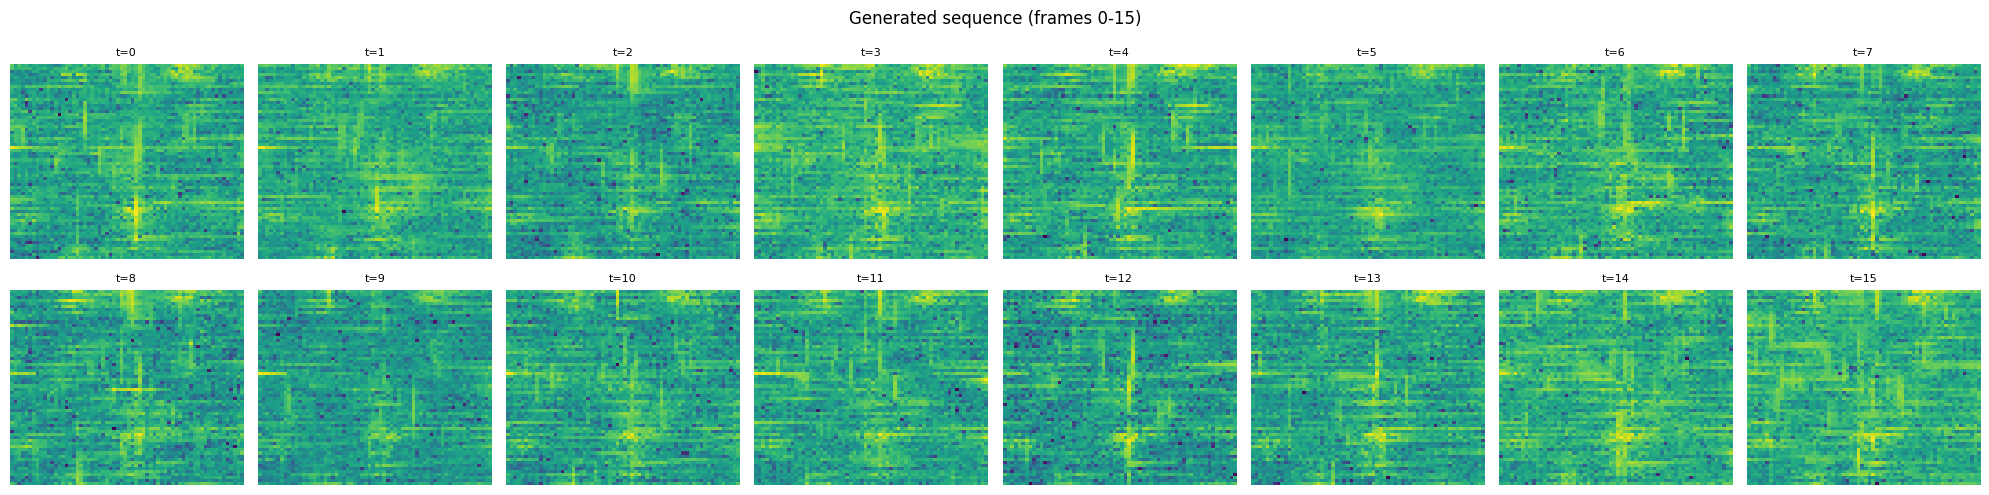

generated vs real metrics: {'velocity_consistency': 6.20924985408783, 'doppler_drift': 0.6837148666381836, 'persistence': 0.028850284637883306, 'marginal_l1': 0.41364479064941406, 'mean_tracks_per_seq': 65.25}
reference (real vs real): {'cfar_detections_per_frame': 116.8046875, 'doppler_drift': 0.7059514191932976, 'marginal_l1': 0.06467437744140625, 'mean_tracks_per_seq': 45.375, 'persistence': 0.07531136967008933, 'velocity_consistency': 3.039933083578944}


In [6]:
from pathlib import Path
if Path('checkpoints/last.pt').exists():
    from src.sample import generate
    from src.eval.metrics import evaluate_sequences
    gen = generate('checkpoints/last.pt', n_seq=4, device=torch.device('cpu'), steps=50)
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(gen[0, i], origin='lower', cmap='viridis', aspect='auto')
        ax.set_title(f't={i}', fontsize=8); ax.axis('off')
    fig.suptitle('Generated sequence (frames 0-15)'); plt.tight_layout(); plt.show()

    real = torch.stack([denormalize(ds[i]['x'], ds.stats) for i in range(16)])
    print('generated vs real metrics:', evaluate_sequences(gen, real))
    print('reference (real vs real):', yaml.safe_load(open('samples/reference_metrics.yaml')))
else:
    print('No checkpoint yet — phase-1 training still running (checkpoints/last.pt is written every epoch,')
    print('so you can re-run this cell mid-training to watch quality improve).')

## 6. Where things stand / roadmap

1. **Phase 1 (running):** unconditional backbone, L_DiT + L_smooth. Gate: coherent moving targets in samples, metrics vs reference.
2. **Phase 2:** flip `train.phase: 2` → adds L_traj + L_Doppler; gate: velocity-consistency & Doppler-drift improve without hurting marginals.
3. **Phase 3:** flip `train.phase: 3` (+ `cond_dropout`) → motion/env/class conditioning with classifier-free guidance; gate: commanded-vs-measured velocity correlation > 0.8.

Progress ledger: `.superpowers/sdd/progress.md`. Training log: `train_phase1.log` (silent — checkpoint mtime is the heartbeat).